In [64]:
# Auto-reload modules to ensure we use the latest code
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd

# Add parent directory to path to import from src/ - DO THIS FIRST
# Get the notebook's directory, then go up one level to project root
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

# Now import everything - path is set up
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim import Adam

# Import PINN models from external module
from src.pinn_models import PressureHeadNet, WaterTableNet, RichardsPINN
# Import normalization helper from external module
from src.normalization_helper import NormalizationHelper
# Import sampling helpers and loss computation functions from external module
from src.training_utils import (
    SamplingHelpers, 
    compute_losses, 
    apply_weights_and_compute_gradients, 
    apply_weights_fixed_mode
)
# Import WeightManager from external module
from src.training_utils import WeightManager
# Import CachePoolManager from external module
from src.training_utils import CachePoolManager
# Import gradient computation utilities from external module
from src.training_utils import compute_grad_norm, compute_total_grad_norm
# Import TrainingLogger from external module
from src.training_logger import TrainingLogger
#training function
from src.train_loop import train_pinn_pool_batch_autoweight
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(44)
np.random.seed(44)

print("✓ Modules loaded with autoreload enabled")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jasonjing/Documents/smap/SMAP-Recharge-Flux
Using device: cpu
✓ Modules loaded with autoreload enabled


LOADING CALHOUN SOIL MOISTURE DATA

Data loaded:
  Total records: 17521
  Time range: 2017-01-01 01:00:00 to 2018-01-01 00:00:00
  Duration: ~364 days
  Resolution: 30 minutes

REPLACING MISSING VALUE CODES (-9999) WITH NaN
Missing value codes replaced with NaN

Time period selection (date-based):
  Start date: 2017-04-01 00:00:00
  End date:   2017-04-30 00:00:00
  Selected:   1393 points
  Date range: 2017-04-01 00:00:00 to 2017-04-30 00:00:00
  Duration:   29.0 days

Raw data quality (after replacing -9999 with NaN):
----------------------------------------------------------------------
2cm   :  1391 valid,     2 NaN ( 0.14%), range=[0.0746, 0.2007]
15cm  :  1391 valid,     2 NaN ( 0.14%), range=[0.1325, 0.2510]
30cm  :  1388 valid,     5 NaN ( 0.36%), range=[0.1300, 0.2975]
40cm  :  1391 valid,     2 NaN ( 0.14%), range=[0.1706, 0.4003]
60cm  :  1388 valid,     5 NaN ( 0.36%), range=[0.2052, 0.3476]
80cm  :  1388 valid,     5 NaN ( 0.36%), range=[0.2968, 0.4782]

DATA CLEANING: INT

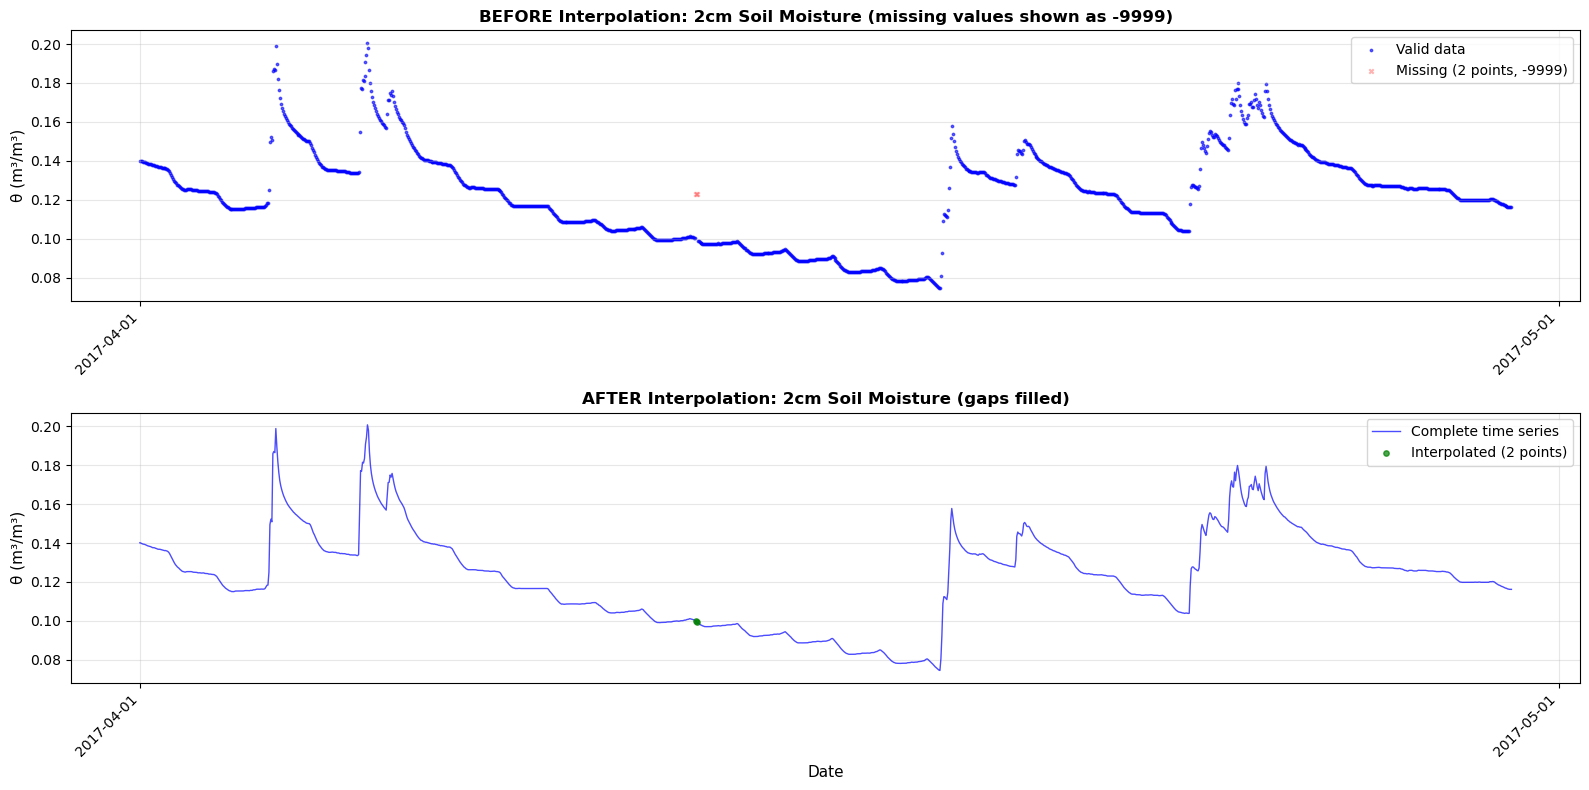


Interpolation Summary for Surface (2cm):
  Original valid points: 1391
  Missing values (-9999): 2
  Points interpolated:   2
  Final valid points:    1393
  Data completeness:     100.0%

DATA LOADING AND CLEANING COMPLETE


In [65]:
# ============================================================================
# LOAD SOIL MOISTURE DATA FROM CALHOUN EXPERIMENTAL FOREST
# ============================================================================

from src.data_loader import load_calhoun_soil_moisture
import matplotlib.dates as mdates

# ============================================================================
# TIME PERIOD SELECTION - Choose one option:
# ============================================================================

# OPTION 1: Load ALL data (default)
soil_data = load_calhoun_soil_moisture(
    filepath='../data/2017_HalfHourly_UTC_ForestSite1.xlsx',
    interpolate=True,
    max_gap_hours=6,
    start_date='2017-04-01',  # March 1, 2017
    end_date='2017-04-30',    # May 31, 2017
    verbose=True
)



# Extract cleaned data for easy access
datetime_col = soil_data['datetime']
times_seconds = soil_data['times_seconds']
theta_2cm = soil_data['theta_2cm']
theta_15cm = soil_data['theta_15cm']
theta_30cm = soil_data['theta_30cm']
theta_40cm = soil_data['theta_40cm']
theta_60cm = soil_data['theta_60cm']
theta_80cm = soil_data['theta_80cm']
depths_names = soil_data['depths_names']

# ============================================================================
# VISUALIZE INTERPOLATION QUALITY (SURFACE LAYER)
# ============================================================================

print("\n" + "="*70)
print("VISUALIZING INTERPOLATION QUALITY (2cm surface layer)")
print("="*70)

# Get raw data for comparison
theta_2cm_raw = soil_data['raw_data'][0]

# Focus on surface layer (2cm) - most important for BC
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Plot 1: Before interpolation
ax1 = axes[0]
valid_mask = ~pd.isna(theta_2cm_raw)
ax1.scatter(datetime_col[valid_mask], theta_2cm_raw[valid_mask], 
           s=3, alpha=0.6, color='blue', label='Valid data')
ax1.scatter(datetime_col[~valid_mask], np.full((~valid_mask).sum(), np.nanmean(theta_2cm_raw)),
           s=10, alpha=0.3, color='red', marker='x', label=f'Missing ({(~valid_mask).sum()} points, -9999)')
ax1.set_ylabel('θ (m³/m³)', fontsize=11)
ax1.set_title('BEFORE Interpolation: 2cm Soil Moisture (missing values shown as -9999)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 2: After interpolation
ax2 = axes[1]
still_nan_mask = pd.isna(theta_2cm)
filled_mask = pd.isna(theta_2cm_raw) & ~pd.isna(theta_2cm)
n_filled_2cm = soil_data['interpolation_stats']['2cm']['n_filled']

ax2.plot(datetime_col, theta_2cm, linewidth=1, alpha=0.7, color='blue', label='Complete time series')
ax2.scatter(datetime_col[filled_mask], theta_2cm[filled_mask],
           s=15, alpha=0.7, color='green', marker='o', label=f'Interpolated ({n_filled_2cm} points)', zorder=5)
if still_nan_mask.any():
    ax2.scatter(datetime_col[still_nan_mask], np.full(still_nan_mask.sum(), np.nanmean(theta_2cm)),
               s=20, alpha=0.5, color='red', marker='x', label=f'Still missing ({still_nan_mask.sum()})', zorder=5)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('θ (m³/m³)', fontsize=11)
ax2.set_title('AFTER Interpolation: 2cm Soil Moisture (gaps filled)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"\nInterpolation Summary for Surface (2cm):")
print(f"  Original valid points: {(~pd.isna(theta_2cm_raw)).sum()}")
print(f"  Missing values (-9999): {(pd.isna(theta_2cm_raw)).sum()}")
print(f"  Points interpolated:   {n_filled_2cm}")
print(f"  Final valid points:    {(~pd.isna(theta_2cm)).sum()}")
print(f"  Data completeness:     {soil_data['interpolation_stats']['2cm']['completeness']:.1f}%")

print("\n" + "="*70)
print("DATA LOADING AND CLEANING COMPLETE")
print("="*70)


THREE-WAY GRADIENT-BASED SAMPLING TEST - SURFACE MOISTURE

Gradient Statistics:
  Max |dθ/dt|:  1.946e-05 m³/m³/s
  Mean |dθ/dt|: 3.668e-07 m³/m³/s
  Min |dθ/dt|:  0.000e+00 m³/m³/s

High-gradient points (top 30%): 418

Generated 450 gradient-weighted samples
Sample range: [1800.0, 2500200.0] s

Sample Breakdown:
  Interpolated:  135 (30.0%)
  Neighbors:     0 (0.0%)
  Baseline:      315 (70.0%)

VISUALIZATION 1: Three-Way Gradient Sampling Details


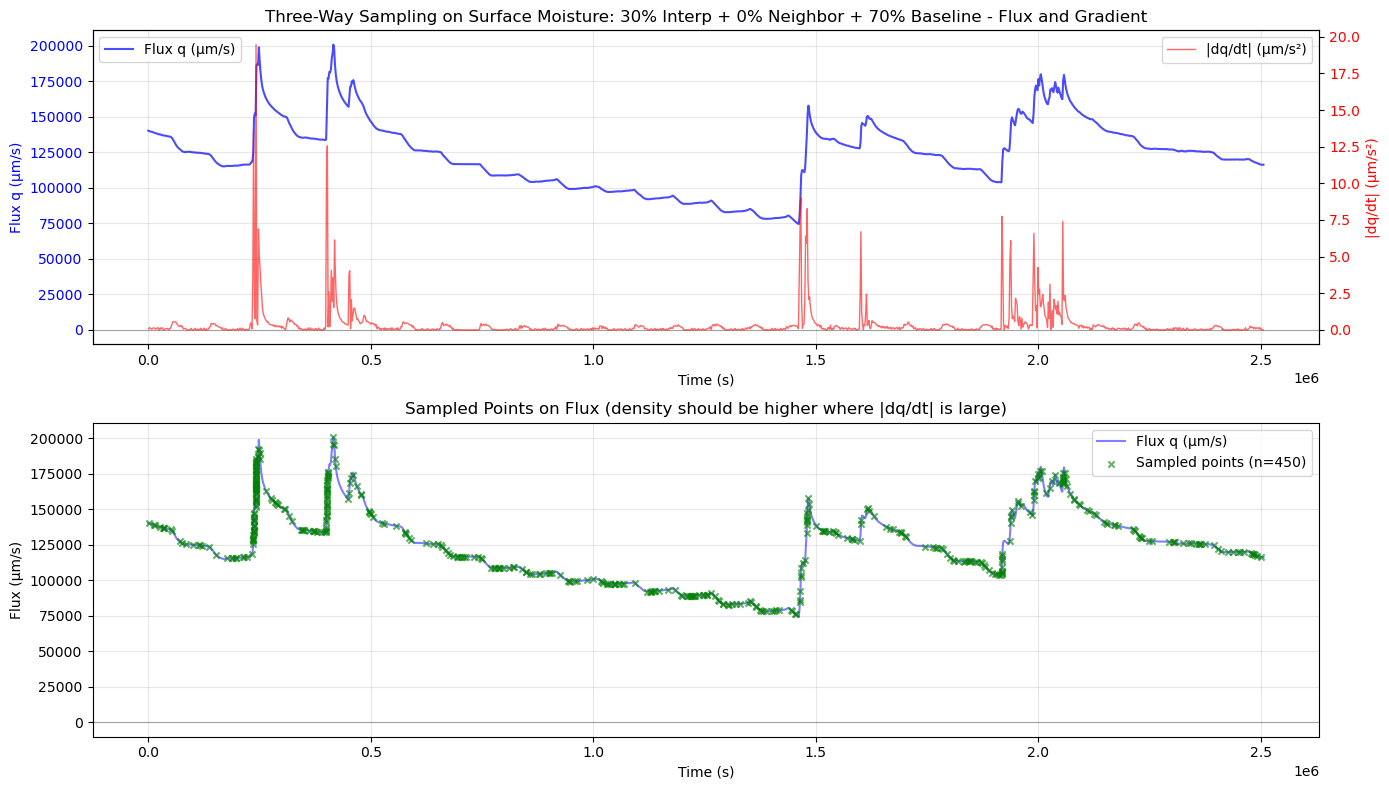


VISUALIZATION 2: Uniform vs Gradient-Based Comparison


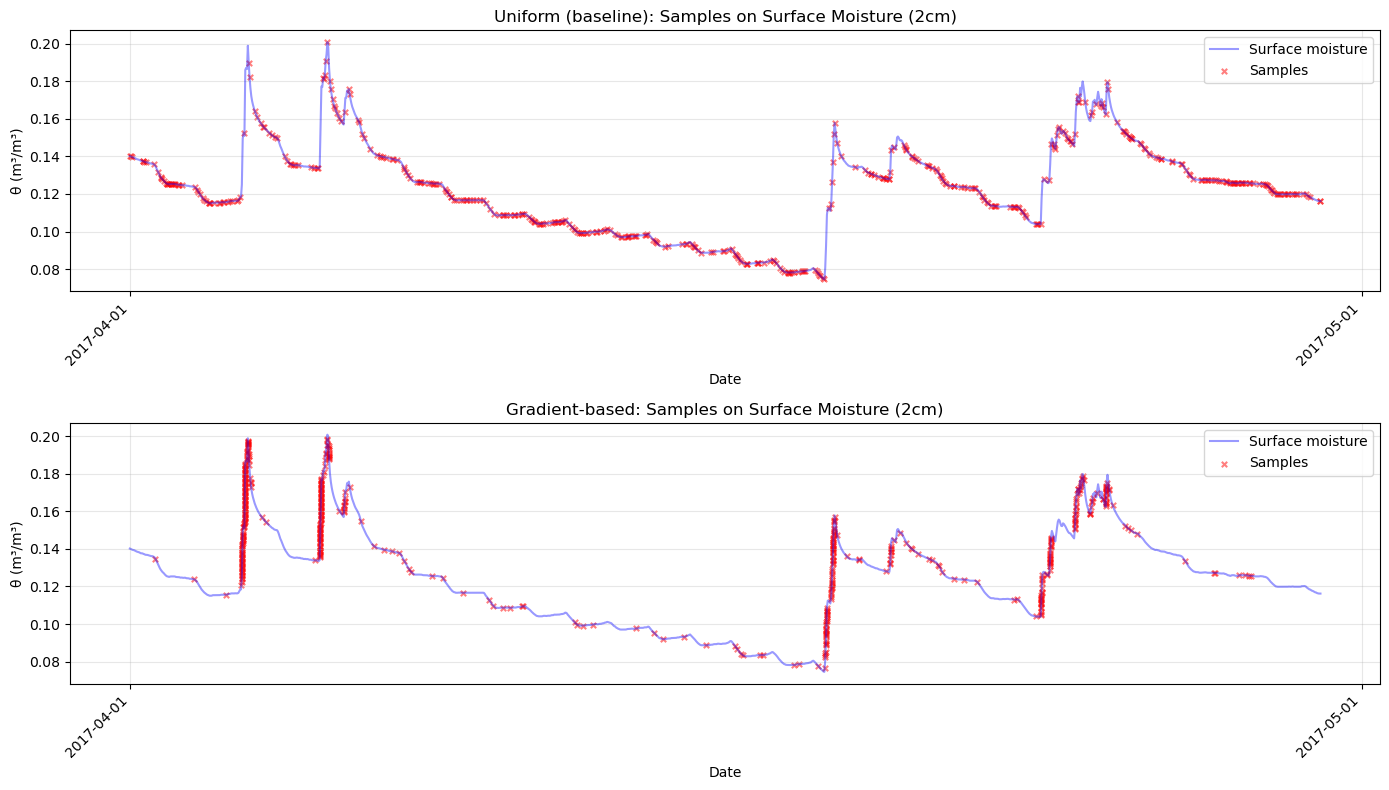


QUANTITATIVE VERIFICATION
Configuration: 30% interp + 0% neighbor + 70% baseline

Gradient Enrichment:
  Average |dθ/dt| at sampled points:  2.518e-06 m³/m³/s
  Average |dθ/dt| overall:            3.668e-07 m³/m³/s
  Enrichment factor:                  6.86x

Sample Composition:
  Interpolated points:  135
  Neighbor points:      0
  Baseline points:      315

Expected: Enrichment > 1.5x (samples concentrated in high-gradient regions)
  → Regions with rapid moisture changes (drying/wetting events)


In [66]:
# ============================================================================
# TEST THREE-WAY GRADIENT-BASED SAMPLING ON SURFACE MOISTURE DATA
# ============================================================================

from src.gradient_based_sampling import (
    gradient_based_sampling,
    visualize_gradient_sampling,
    compare_sampling_methods,
    compute_gradient_weights
)

# Prepare surface moisture data for sampling
theta_surface = theta_2cm.copy()
times_surface = times_seconds.copy()

# Remove NaN values for gradient-based sampling
valid_mask = ~pd.isna(theta_surface)
theta_clean = theta_surface[valid_mask]
times_clean = times_surface[valid_mask]
datetime_clean = datetime_col[valid_mask]

# Convert to tensors - ensure numeric type
theta0_times_t = torch.tensor(np.array(times_clean, dtype=np.float32), dtype=torch.float32).to(device)
theta0_values = torch.tensor(np.array(theta_clean, dtype=np.float32), dtype=torch.float32).to(device)

print("\n" + "="*70)
print("THREE-WAY GRADIENT-BASED SAMPLING TEST - SURFACE MOISTURE")
print("="*70)

# Compute gradient weights
gradient_weights, gradients = compute_gradient_weights(theta0_times_t, theta0_values, device)

print(f"\nGradient Statistics:")
print(f"  Max |dθ/dt|:  {gradients.abs().max().item():.3e} m³/m³/s")
print(f"  Mean |dθ/dt|: {gradients.abs().mean().item():.3e} m³/m³/s")
print(f"  Min |dθ/dt|:  {gradients.abs().min().item():.3e} m³/m³/s")

# Find high-gradient regions
high_grad_threshold = gradients.abs().quantile(0.7)  # Top 30%
high_grad_mask = gradients.abs() > high_grad_threshold
print(f"\nHigh-gradient points (top 30%): {high_grad_mask.sum().item()}")

# Test parameters - THREE-WAY SAMPLING
batch_size_bc = 450
interp_ratio = 0.30      # 80% from gradient-interpolated points
neighbor_ratio = 0.00    # 5% from neighbors of high-gradient regions
baseline_ratio = 0.7    # 15% from uniform baseline
neighbor_expansion = 0   # ±2 neighbors around high gradients
power = 2.0              # >1 emphasizes high gradients more aggressively
gradient_threshold = 0.7

# Generate three-way gradient-based samples
t_bc_gradient, sample_info = gradient_based_sampling(
    theta0_times_t,
    theta0_values,
    batch_size_bc,
    device=device,
    use_interpolation=True,
    interp_ratio=interp_ratio,
    neighbor_ratio=neighbor_ratio,
    baseline_ratio=baseline_ratio,
    neighbor_expansion=neighbor_expansion,
    gradient_threshold=gradient_threshold,
    power=power
)

print(f"\nGenerated {len(t_bc_gradient)} gradient-weighted samples")
print(f"Sample range: [{t_bc_gradient.min():.1f}, {t_bc_gradient.max():.1f}] s")
print(f"\nSample Breakdown:")
print(f"  Interpolated:  {sample_info['n_interp_samples']} ({sample_info['actual_ratios']['interp']*100:.1f}%)")
print(f"  Neighbors:     {sample_info['n_neighbor_samples']} ({sample_info['actual_ratios']['neighbor']*100:.1f}%)")
print(f"  Baseline:      {sample_info['n_baseline_samples']} ({sample_info['actual_ratios']['baseline']*100:.1f}%)")

# Visualize gradient-based sampling
print("\n" + "="*70)
print("VISUALIZATION 1: Three-Way Gradient Sampling Details")
print("="*70)
visualize_gradient_sampling(
    theta0_times_t,
    theta0_values,
    t_bc_gradient,
    sample_info,
    title=f'Three-Way Sampling on Surface Moisture: {interp_ratio*100:.0f}% Interp + {neighbor_ratio*100:.0f}% Neighbor + {baseline_ratio*100:.0f}% Baseline'
)
plt.show()

# Compare uniform vs gradient-based sampling
print("\n" + "="*70)
print("VISUALIZATION 2: Uniform vs Gradient-Based Comparison")
print("="*70)

configs = [
    {"name": "Uniform (baseline)", "interp": 0.0, "neighbor": 0.0, "baseline": 1.0},
    {"name": "Gradient-based", "interp": 0.80, "neighbor": 0.05, "baseline": 0.15},
]

fig, axes = plt.subplots(len(configs), 1, figsize=(14, 4*len(configs)))
if len(configs) == 1:
    axes = [axes]

for i, config in enumerate(configs):
    # Generate samples
    if config['interp'] == 0.0:
        # Pure uniform
        uniform_idx = torch.randperm(len(theta0_times_t), device=device)[:batch_size_bc]
        t_bc_test = theta0_times_t[uniform_idx]
    else:
        t_bc_test, info_test = gradient_based_sampling(
            theta0_times_t, theta0_values, batch_size_bc, device=device,
            use_interpolation=(config['interp'] > 0),
            interp_ratio=config['interp'],
            neighbor_ratio=config['neighbor'],
            baseline_ratio=config['baseline'],
            neighbor_expansion=2,
            gradient_threshold=0.7,
            power=power
        )

    samples_np = t_bc_test.detach().cpu().numpy().flatten()
    times_np = theta0_times_t.cpu().numpy().flatten()
    values_np = theta0_values.cpu().numpy().flatten()

    # Convert times to datetime for plotting
    datetime_samples = datetime_clean.iloc[0] + pd.to_timedelta(samples_np, unit='s')
    
    # Scatter on moisture
    ax = axes[i]
    ax.plot(datetime_clean, values_np, 'b-', linewidth=1.5, alpha=0.4, label='Surface moisture')
    ax.scatter(datetime_samples, np.interp(samples_np, times_np, values_np),
            s=15, c='red', alpha=0.5, marker='x', label='Samples')
    ax.set_ylabel('θ (m³/m³)')
    ax.set_xlabel('Date')
    ax.set_title(f"{config['name']}: Samples on Surface Moisture (2cm)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Quantitative verification
print("\n" + "="*70)
print("QUANTITATIVE VERIFICATION")
print("="*70)

# Check if samples are concentrated in high-gradient regions
samples_np = t_bc_gradient.detach().cpu().numpy().flatten()
times_np = theta0_times_t.cpu().numpy().flatten()

# For each sample, find nearest data point and check its gradient
sample_gradients = []
for s in samples_np:
    idx = torch.argmin(torch.abs(theta0_times_t.flatten() - s))
    if idx < len(gradients):
        sample_gradients.append(gradients[idx].abs().item())

sample_grad_mean = np.mean(sample_gradients)
overall_grad_mean = gradients.abs().mean().item()

print(f"Configuration: {interp_ratio*100:.0f}% interp + {neighbor_ratio*100:.0f}% neighbor + {baseline_ratio*100:.0f}% baseline")
print(f"\nGradient Enrichment:")
print(f"  Average |dθ/dt| at sampled points:  {sample_grad_mean:.3e} m³/m³/s")
print(f"  Average |dθ/dt| overall:            {overall_grad_mean:.3e} m³/m³/s")
print(f"  Enrichment factor:                  {sample_grad_mean/overall_grad_mean:.2f}x")
print(f"\nSample Composition:")
print(f"  Interpolated points:  {sample_info['n_interp_samples']}")
print(f"  Neighbor points:      {sample_info['n_neighbor_samples']}")
print(f"  Baseline points:      {sample_info['n_baseline_samples']}")
print("\nExpected: Enrichment > 1.5x (samples concentrated in high-gradient regions)")
print("  → Regions with rapid moisture changes (drying/wetting events)")
print("="*70)

In [67]:
# ============================================================================
# TRAINING CONFIGURATION - MOISTURE BC ONLY
# ============================================================================

soil_params = {
    'theta_s': 0.4,
    'theta_r': 0.1,
    'alpha': 0.005,
    'n': 1.3,
    'Ks': 1e-5,
    'l': 0.5
}

# Define network configurations
h_net_config = {'hidden_dim': 64, 'num_layers': 4}
zb_net_config = {'hidden_dim': 32, 'num_layers': 3}

# ============================================================================
# PREPARE MOISTURE BC DATA
# ============================================================================

# Prepare theta0_data tuple for training (times, moisture values)
# Remove NaN values from surface moisture data
valid_mask = ~pd.isna(theta_2cm)
theta0_times = times_seconds[valid_mask]
theta0_values = theta_2cm[valid_mask]

# Convert to numpy arrays to ensure proper type
theta0_times = np.array(theta0_times, dtype=np.float64)
theta0_values = np.array(theta0_values, dtype=np.float64)

theta0_data = (theta0_times, theta0_values)

print("="*70)
print("TRAINING WITH MOISTURE BC (Dirichlet)")
print("  Surface BC: θ(z=0, t) = θ₀(t)")
print(f"  Data points: {len(theta0_data[0])}")
print(f"  Duration: {theta0_data[0][-1]/86400:.1f} days")
print(f"  Moisture range: {min(theta0_data[1]):.4f} - {max(theta0_data[1]):.4f} m³/m³")
print(f"  Soil: θr={soil_params['theta_r']:.3f}, θs={soil_params['theta_s']:.3f}")
print("="*70 + "\n")

# ============================================================================
# TRAIN PINN WITH MOISTURE BC
# ============================================================================

print("Starting PINN Training with Moisture BC")
print("="*70)

# Gradient-based sampling parameters
batch_size_bc = 250
interp_ratio = 0.80
neighbor_ratio = 0.05
baseline_ratio = 0.15
neighbor_expansion = 2
gradient_threshold = 0.7
power = 2.0

# Train with pool + batch approach using gradient-based boundary sampling
model_pool, losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs = train_pinn_pool_batch_autoweight(
    soil_params=soil_params,
    theta0_data=theta0_data,  # Moisture BC data - REQUIRED
    Sy=0.3,
    zr=0.5,
    h_net_config=h_net_config,
    zb_net_config=zb_net_config,
    L=4.0,
    S_max=1e-7,
    n_epochs=20000,
    learning_rate=1e-3,
    zb_initial=1,
    weight_update_freq=1e10,
    weight_lr=0.1,
    use_initial_scales=True,
    
    # Pool + batch parameters
    cache_size=10000,
    batch_size=500,
    resample_freq=100,
    boundary_ratio=0.7,
    high_residual_ratio=0.6,
    temperature=0.3,
    
    # Gradient-based boundary sampling parameters
    batch_size_bc=batch_size_bc,
    interp_ratio=interp_ratio,
    neighbor_ratio=neighbor_ratio,
    baseline_ratio=baseline_ratio,
    gradient_neighbor_expansion=neighbor_expansion,
    gradient_threshold=gradient_threshold,
    gradient_power=power,
    
    # Device and checkpointing
    device=device,
    checkpoint_dir='checkpoints_train',
    checkpoint_freq=5000,
)

print("\n" + "="*70)
print("Training Complete!")
print("="*70)

TRAINING WITH MOISTURE BC (Dirichlet)
  Surface BC: θ(z=0, t) = θ₀(t)
  Data points: 1393
  Duration: 29.0 days
  Moisture range: 0.0746 - 0.2007 m³/m³
  Soil: θr=0.100, θs=0.400

Starting PINN Training with Moisture BC

NORMALIZATION SCALES
Length scale (L):           4.000 m
Head scale (H_*):           4.000 m
Conductivity scale (K_*):   1.00e-05 m/s
Flux scale (Q_*):           1.00e-05 m/s
Water content span (θ_*):   0.300
Time scale (T):             1.20e+05 s (33.33 hours)
Dimensionless α̃:            0.0200
Dimensionless S̃_max:        0.0400

Fixed weights mode enabled (weight_update_freq=10000000000.0 >= n_epochs=20000)
Checkpointing enabled: saving every 5000 epochs to checkpoints_train/
Training for 20000 epochs | lr=0.001
Device: cpu | GPUs available: 0
Adaptive weighting: updating every 10000000000.0 epochs
Pool + Batch: cache_size=10000, batch_size=500, resample_freq=100
Boundary ratio: 70.0%, High residual ratio: 60.0%
Time domain from theta0: t∈[0.000, 2505600.000], z ad

KeyboardInterrupt: 

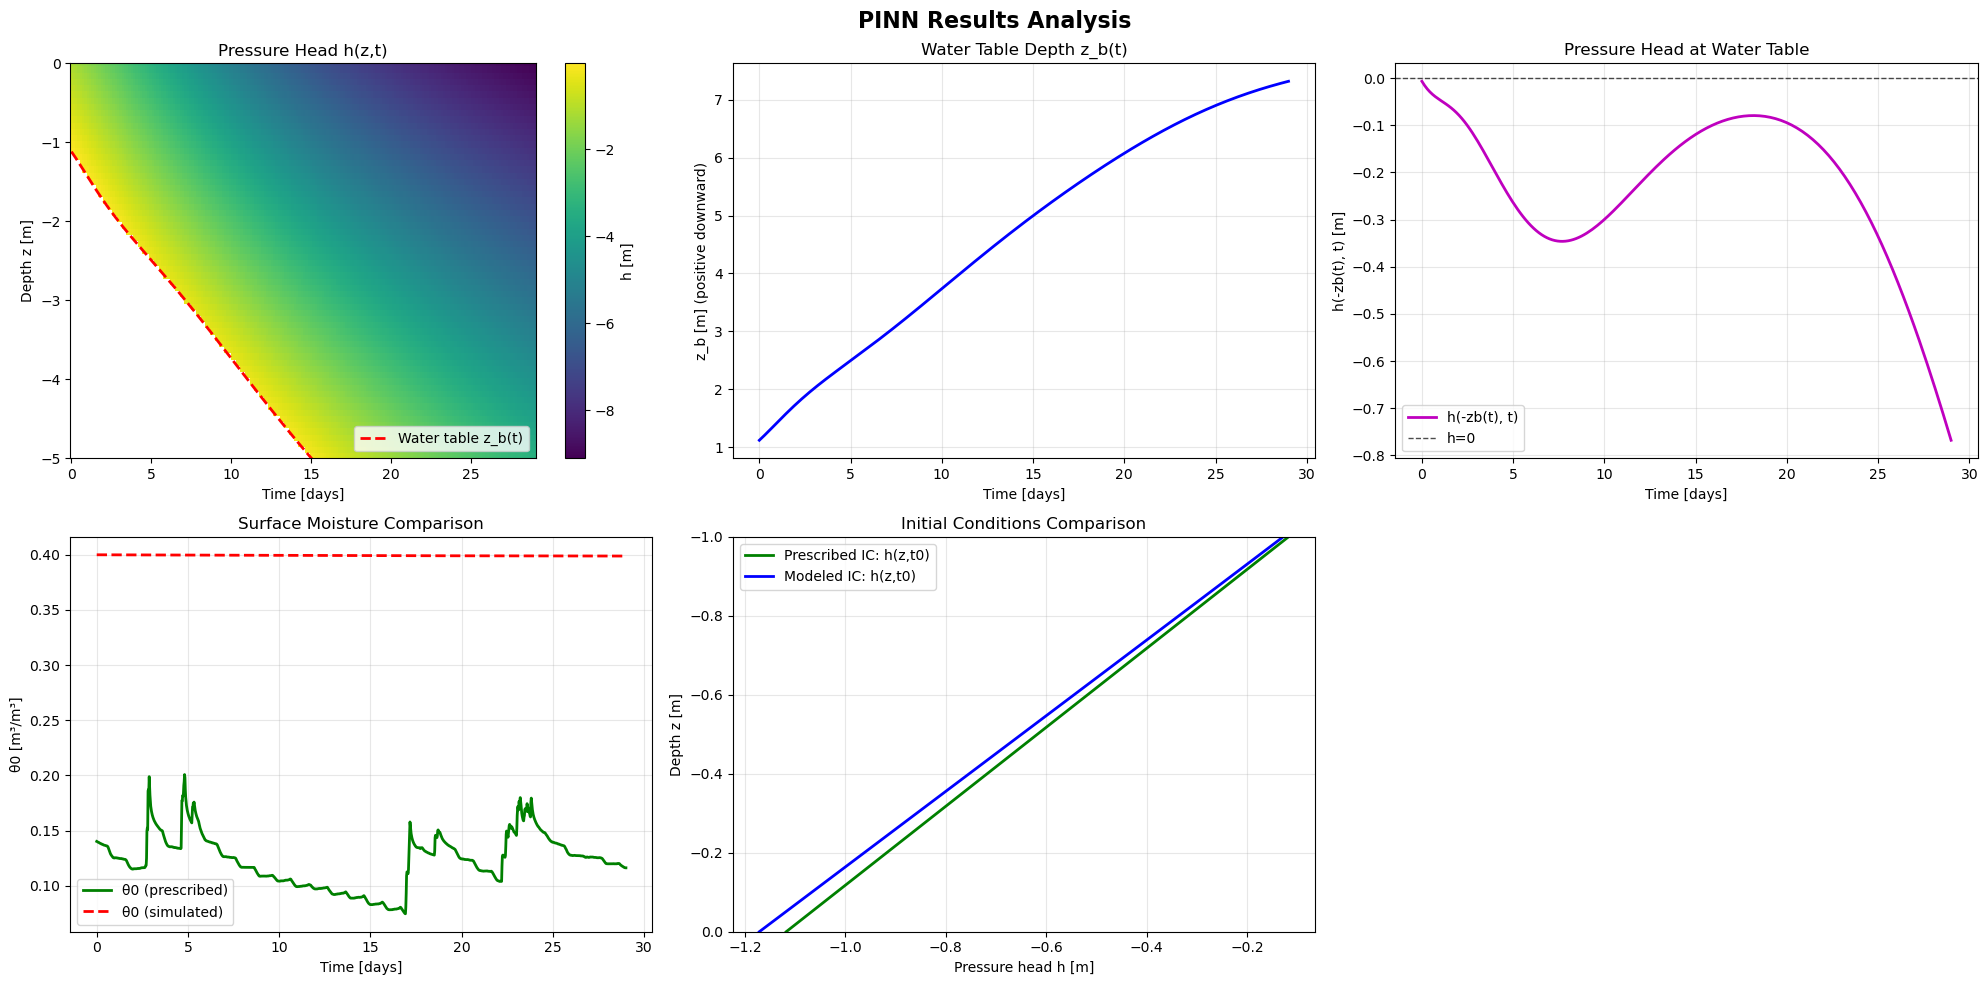


Summary Statistics:
Water table depth range: 1.118 to 7.320 m
Surface head range: -9.104 to -1.171 m
h(-zb(t), t) range: -0.767929 to -0.006704 m
Max |h(-zb(t), t)|: 0.767929 m (should be close to 0)
Max IC error: 0.053541 m


In [ ]:
# Import visualization functions from external module
from src.visualization import plot_comprehensive_results

# Use theta0_data for moisture BC visualization
plot_comprehensive_results(model_pool, theta0_data, soil_params, device=device)

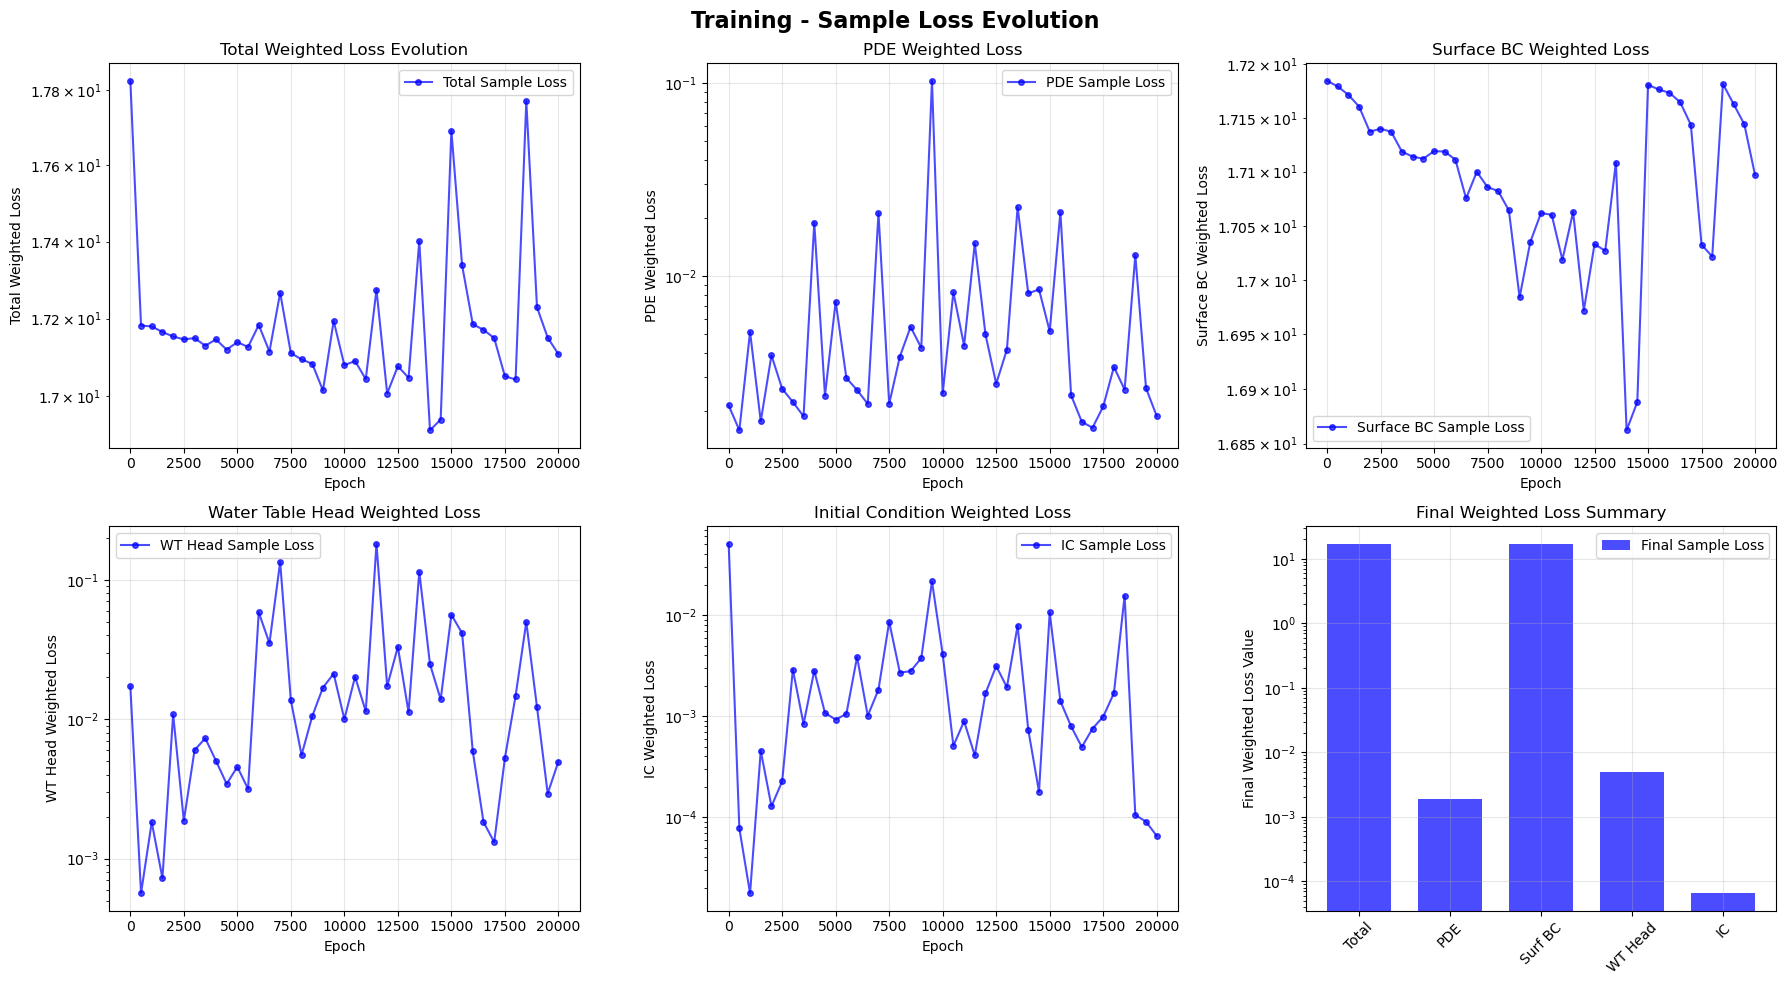

In [ ]:
# Import and use the loss plotting function from external module
from src.visualization import plot_training_losses

# Plot the sample losses (computed over full dataset every 500 epochs)
# This gives a smoother, less noisy view of the loss evolution
plot_training_losses(losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs)